#Create graphs and subgraphs

Final Code for differnt textures 


Processing: B-cell_infiltration
  Total rows: 50
  GAT rows: 5
  Unique identifiers: ['GAT' 'Person 1' 'Person 2' 'Person 3' 'Person 4' 'Person 5' 'Person 6'
 'Person 7' 'Person 8' 'Person 9']
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_B-cell_infiltration.png


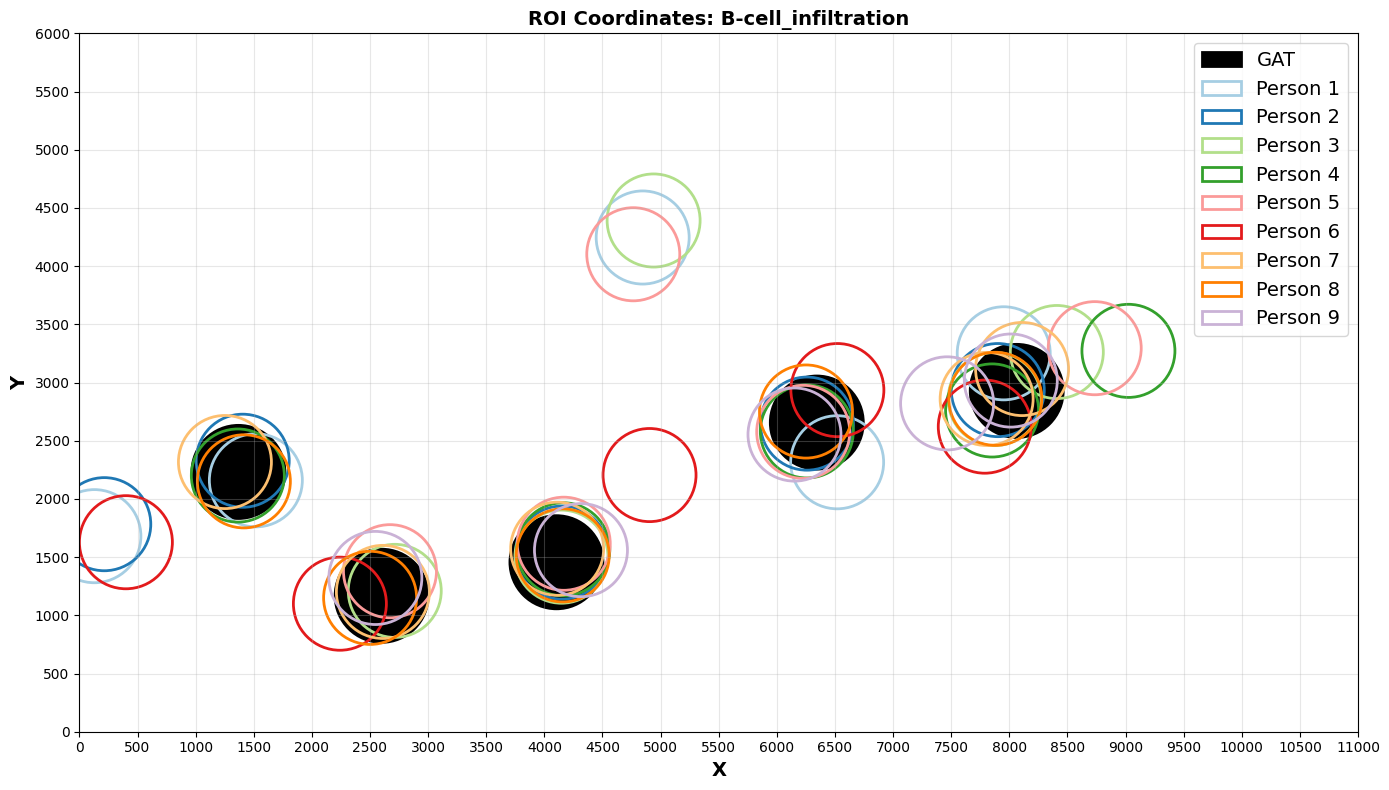


Processing: Inflammatory_zone
  Total rows: 50
  GAT rows: 5
  Unique identifiers: ['GAT' 'Person 1' 'Person 2' 'Person 3' 'Person 4' 'Person 5' 'Person 6'
 'Person 7' 'Person 8' 'Person 9']
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_Inflammatory_zone.png


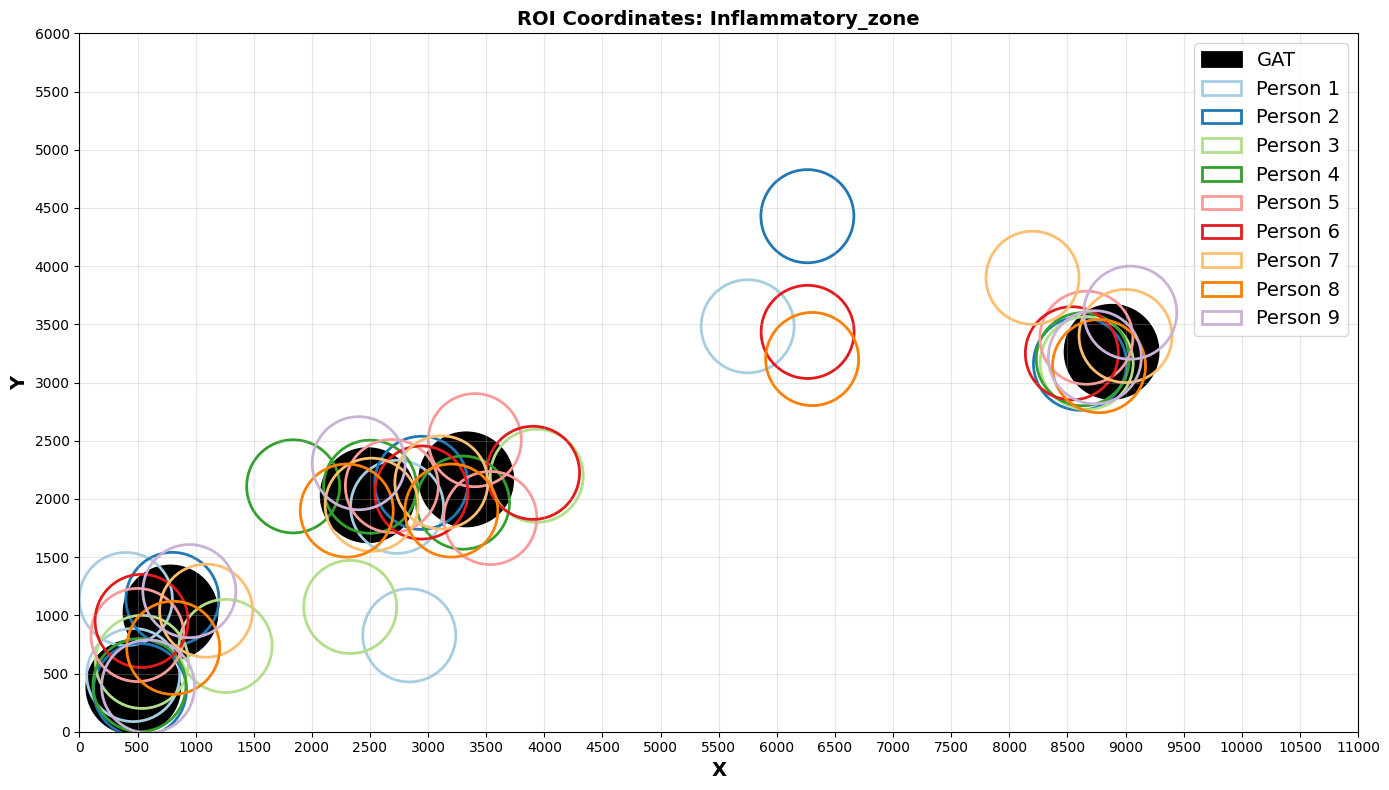


Processing: Oxidative_stress_regulation
  Total rows: 50
  GAT rows: 5
  Unique identifiers: ['GAT' 'Person 1' 'Person 2' 'Person 3' 'Person 4' 'Person 5' 'Person 6'
 'Person 7' 'Person 8' 'Person 9']
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_Oxidative_stress_regulation.png


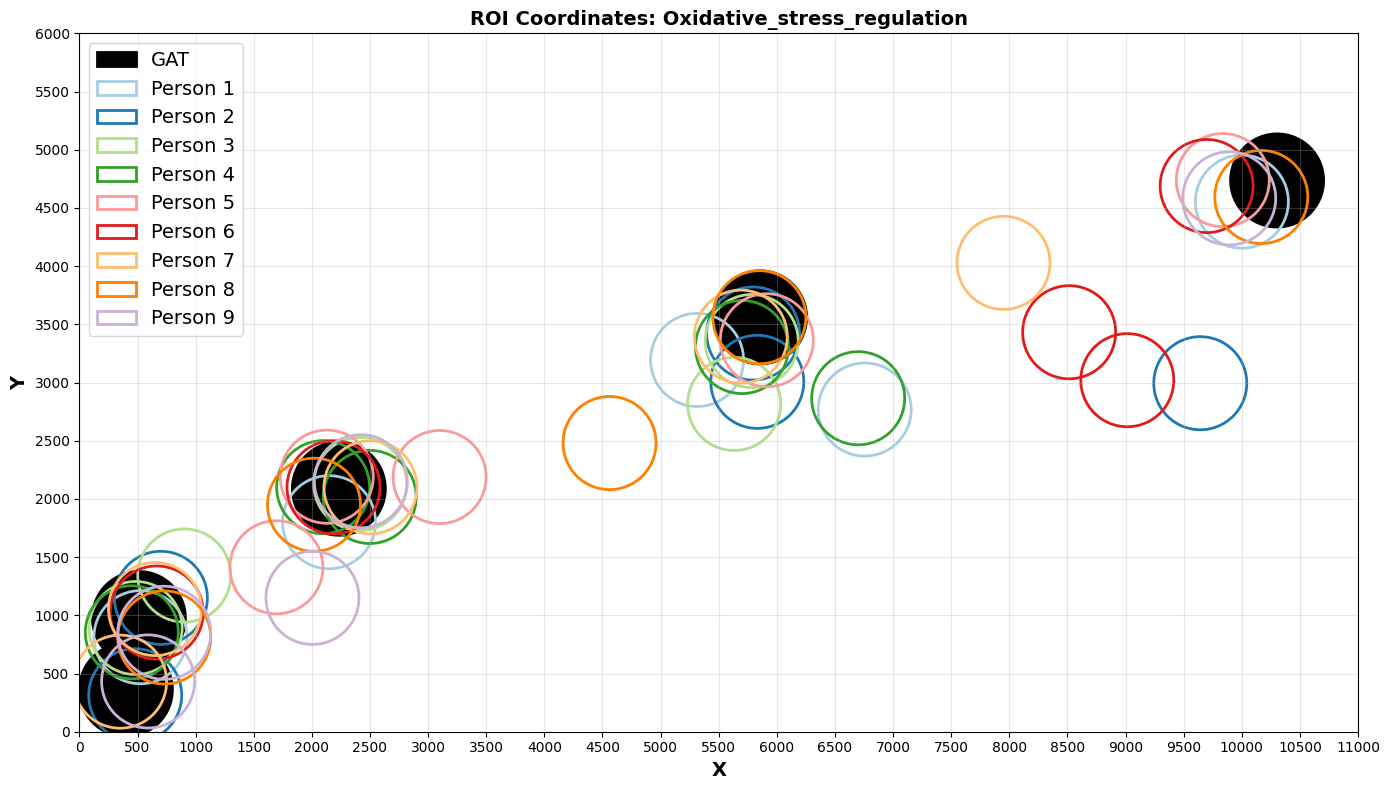


Processing: T-cell_maturation
  Total rows: 50
  GAT rows: 5
  Unique identifiers: ['GAT' 'Person 1' 'Person 2' 'Person 3' 'Person 4' 'Person 5' 'Person 6'
 'Person 7' 'Person 8' 'Person 9']
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_T-cell_maturation.png


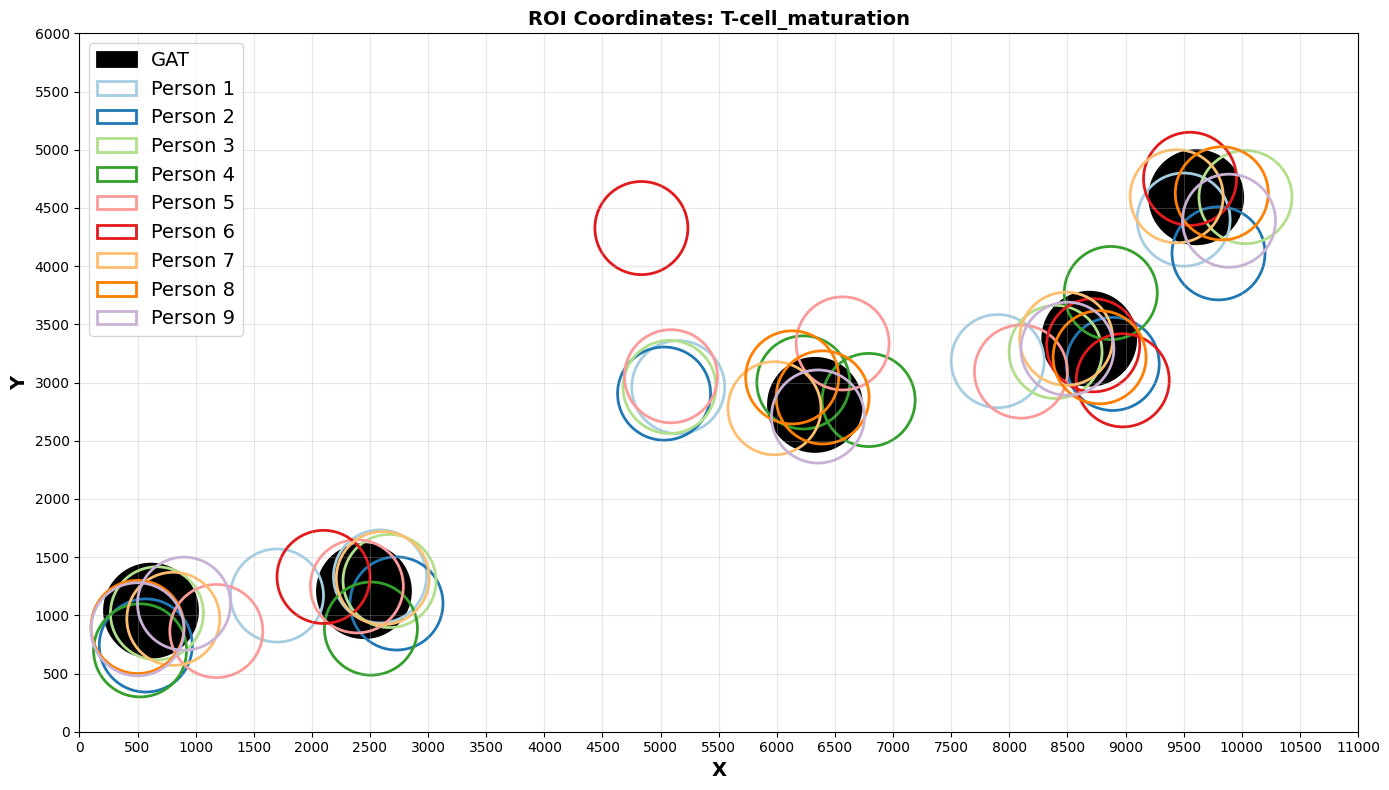


✓ All 2D plots created successfully!

Creating 3D Scatter Plots for each region/topic...

Processing 3D plot: B-cell_infiltration


C:\Users\hosse\AppData\Local\Temp\ipykernel_24204\502773876.py:209: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_coords, y_coords, z_coords,


  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\3d_scatter_B-cell_infiltration.png


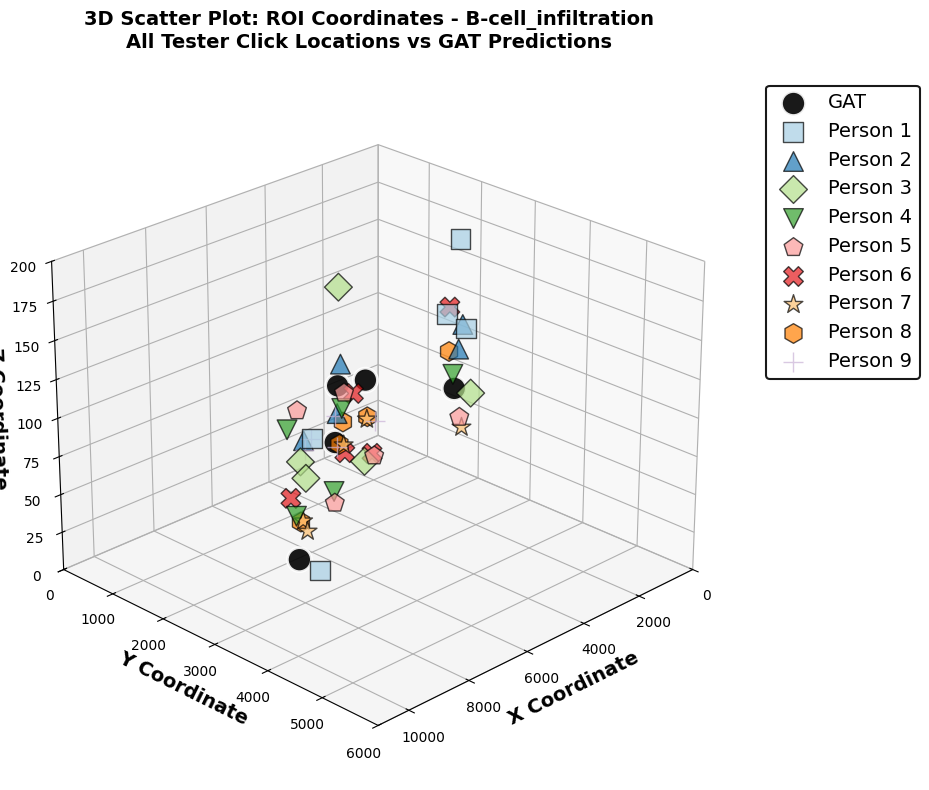


Processing 3D plot: Inflammatory_zone


C:\Users\hosse\AppData\Local\Temp\ipykernel_24204\502773876.py:209: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_coords, y_coords, z_coords,


  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\3d_scatter_Inflammatory_zone.png


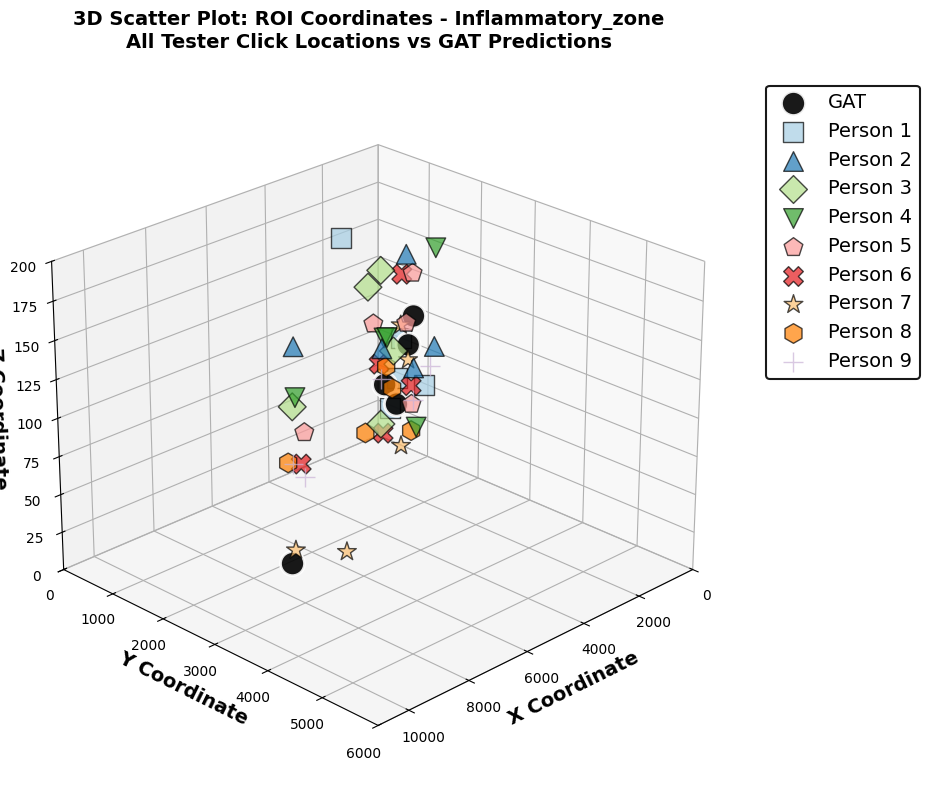


Processing 3D plot: Oxidative_stress_regulation


C:\Users\hosse\AppData\Local\Temp\ipykernel_24204\502773876.py:209: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_coords, y_coords, z_coords,


  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\3d_scatter_Oxidative_stress_regulation.png


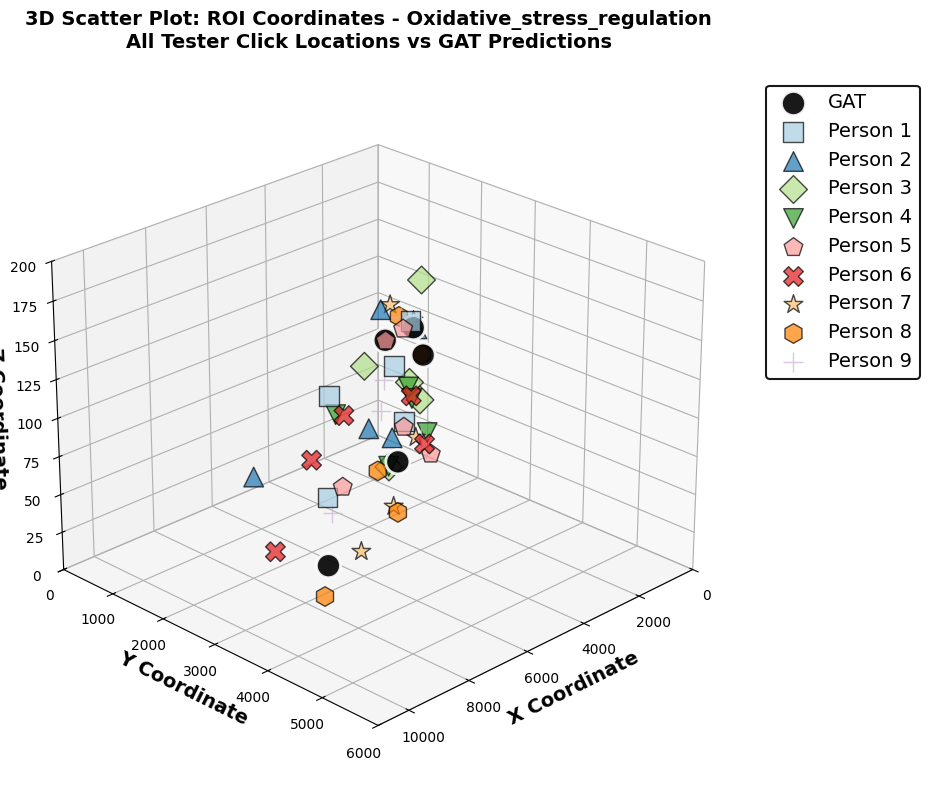


Processing 3D plot: T-cell_maturation


C:\Users\hosse\AppData\Local\Temp\ipykernel_24204\502773876.py:209: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_coords, y_coords, z_coords,


  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\3d_scatter_T-cell_maturation.png


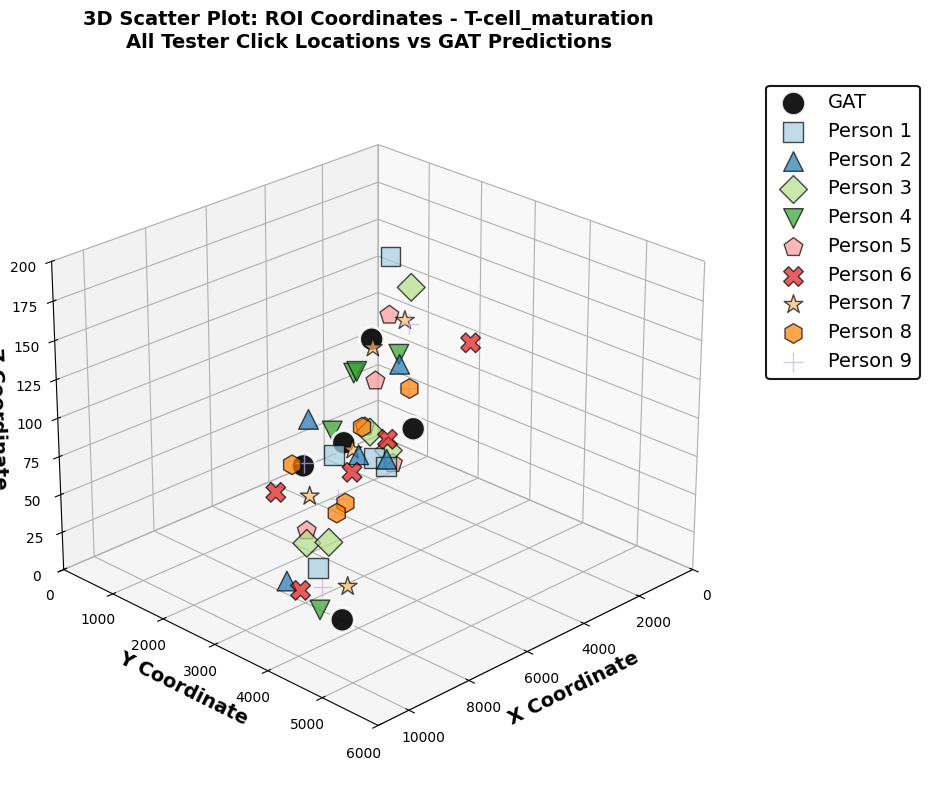


✓ All 3D scatter plots created successfully!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.ticker import MultipleLocator
from pathlib import Path
import numpy as np

# Define file paths
base_dir = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

# Color palette
colors = {
    'GAT': '#000000',           # Black (filled)
    'Person 1': '#a6cee3',      # Light blue
    'Person 2': '#1f78b4',       # Blue
    'Person 3': '#b2df8a',       # Light green
    'Person 4': '#33a02c',       # Green
    'Person 5': '#fb9a99',       # Light red
    'Person 6': '#e31a1c',       # Red
    'Person 7': '#fdbf6f',       # Light orange
    'Person 8': '#ff7f00',       # Orange
    'Person 9': '#cab2d6'        # Light purple
}

# Markers for 3D scatter plot
markers_3d = {
    'GAT': 'o',           # Circle
    'Person 1': 's',      # Square
    'Person 2': '^',      # Triangle up
    'Person 3': 'D',      # Diamond
    'Person 4': 'v',      # Triangle down
    'Person 5': 'p',      # Pentagon
    'Person 6': 'X',      # X
    'Person 7': '*',      # Star
    'Person 8': 'h',      # Hexagon
    'Person 9': '+'       # Plus
}

# Circle parameters
circle_radius = 400
stroke_width = 2

# Process each CSV file
for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        print(f"Warning: CSV file not found: {csv_path}")
        continue
    
    # Read CSV file (header=0 means first row is header, data starts from row 1)
    df = pd.read_csv(csv_path, header=0)
    
    # Extract sheet name from filename
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    print(f"\nProcessing: {sheet_name}")
    print(f"  Total rows: {len(df)}")
    print(f"  GAT rows: {len(df[df.iloc[:, 0] == 'GAT'])}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Group data by identifier (first column) and plot
    identifiers = df.iloc[:, 0].unique()  # Get unique identifiers from first column
    print(f"  Unique identifiers: {identifiers}")
    
    for identifier in identifiers:
        # Get all rows for this identifier
        identifier_data = df[df.iloc[:, 0] == identifier]
        
        # Get color for this identifier
        if identifier in colors:
            color = colors[identifier]
        else:
            # Default color if not in palette
            color = '#808080'
            print(f"  Warning: No color defined for '{identifier}', using gray")
        
        # Determine if filled (GAT) or hollow (others)
        is_filled = (identifier == 'GAT')
        
        # Plot circles for each row
        for idx, row in identifier_data.iterrows():
            # Third column (index 2) is x, fourth column (index 3) is y
            x_val = row.iloc[2]  # x coordinate
            y_val = row.iloc[3]  # y coordinate
            
            # Check if valid
            if pd.notna(x_val) and pd.notna(y_val):
                try:
                    x_float = float(x_val)
                    y_float = float(y_val)
                    
                    if not (np.isnan(x_float) or np.isnan(y_float)):
                        # Create circle
                        if is_filled:
                            circle = Circle((x_float, y_float), circle_radius,
                                          fill=True, facecolor=color,
                                          edgecolor=color, linewidth=stroke_width,
                                          label=identifier if idx == identifier_data.index[0] else '')
                        else:
                            circle = Circle((x_float, y_float), circle_radius,
                                          fill=False, edgecolor=color,
                                          linewidth=stroke_width,
                                          label=identifier if idx == identifier_data.index[0] else '')
                        ax.add_patch(circle)
                except (ValueError, TypeError):
                    continue
    
    # Set axis limits
    ax.set_xlim(0, 11000)
    ax.set_ylim(0, 6000)
    # Set tick step to 100
    ax.xaxis.set_major_locator(MultipleLocator(500))
    ax.yaxis.set_major_locator(MultipleLocator(500))
    # Set labels and title
    ax.set_xlabel('X', fontsize=14,fontweight='bold')
    ax.set_ylabel('Y', fontsize=14,fontweight='bold')
    ax.set_title(f'ROI Coordinates: {sheet_name}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=14)
    
    # Save plot
    plt.tight_layout()
    output_path = base_dir / f'roi_plot_{sheet_name}.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {output_path}")
    plt.show()

print(f"\n✓ All 2D plots created successfully!")

# Now create 3D scatter plots for each topic
print(f"\n{'='*70}")
print("Creating 3D Scatter Plots for each region/topic...")
print(f"{'='*70}")

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        print(f"Warning: CSV file not found: {csv_path}")
        continue
    
    # Read CSV file
    df = pd.read_csv(csv_path)
    
    # Extract sheet name from filename
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    print(f"\nProcessing 3D plot: {sheet_name}")
    
    # Create 3D figure
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Group data by identifier and plot
    identifiers = df.iloc[:, 0].unique()
    
    for identifier in identifiers:
        # Get all rows for this identifier
        identifier_data = df[df.iloc[:, 0] == identifier]
        
        # Get color and marker for this identifier
        if identifier in colors:
            color = colors[identifier]
            marker = markers_3d[identifier]
        else:
            color = '#808080'
            marker = 'o'
            print(f"  Warning: No color/marker defined for '{identifier}', using gray")
        
        # Extract coordinates (x, y, z)
        x_coords = []
        y_coords = []
        z_coords = []
        
        for idx, row in identifier_data.iterrows():
            x_val = row.iloc[2]  # x coordinate
            y_val = row.iloc[3]  # y coordinate
            z_val = row.iloc[4]  # z coordinate
            
            # Check if valid
            if pd.notna(x_val) and pd.notna(y_val) and pd.notna(z_val):
                try:
                    x_float = float(x_val)
                    y_float = float(y_val)
                    z_float = float(z_val)
                    
                    if not (np.isnan(x_float) or np.isnan(y_float) or np.isnan(z_float)):
                        x_coords.append(x_float)
                        y_coords.append(y_float)
                        z_coords.append(z_float)
                except (ValueError, TypeError):
                    continue
        
        # Plot 3D scatter points
        if len(x_coords) > 0:
            # Different sizes for GAT vs others
            size = 300 if identifier == 'GAT' else 200
            alpha = 0.9 if identifier == 'GAT' else 0.7
            edge_color = 'white' if identifier == 'GAT' else 'black'
            line_width = 2 if identifier == 'GAT' else 1
            
            ax.scatter(x_coords, y_coords, z_coords,
                      c=color, marker=marker, s=size,
                      label=identifier, alpha=alpha,
                      edgecolors=edge_color, linewidths=line_width,
                      depthshade=True)
    
    # Customize 3D plot
    ax.set_xlabel('X Coordinate', fontsize=14, fontweight='bold')
    ax.set_ylabel('Y Coordinate', fontsize=14, fontweight='bold')
    ax.set_zlabel('Z Coordinate', fontsize=14, fontweight='bold')
    ax.set_title(f'3D Scatter Plot: ROI Coordinates - {sheet_name}\nAll Tester Click Locations vs GAT Predictions', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Set axis limits
    ax.set_xlim(0, 11000)
    ax.set_ylim(0, 6000)
    ax.set_zlim(0, 200)
    
    # Add legend
    legend = ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=14,
                      framealpha=0.9, edgecolor='black')
    # Set linewidth for legend frame
    legend.get_frame().set_linewidth(1.5)
    
    # Adjust viewing angle
    ax.view_init(elev=25, azim=45)
    
    # Save plot
    plt.tight_layout()
    output_path = base_dir / f'3d_scatter_{sheet_name}.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {output_path}")
    plt.show()

print(f"\n✓ All 3D scatter plots created successfully!")


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import math

# Define file paths
base_dir = Path(r"D:\BIOvisdata\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

# Sphere parameters (3D - considering volume)
sphere_radius = 400
z_tolerance = 50  # Z difference tolerance: ±50 considered as same volume

# Function to calculate volume overlap percentage between two spheres
# With special handling: if Z difference <= 50, consider as maximum overlap
def calculate_sphere_overlap_with_z_tolerance(center1, center2, radius, z_tol):
    """
    Calculate volume overlap percentage between two spheres of equal radius.
    Special rule: If Z difference <= z_tol, consider as maximum overlap (100%).
    Returns: overlap_volume / sphere_volume * 100
    """
    x1, y1, z1 = center1[0], center1[1], center1[2]
    x2, y2, z2 = center2[0], center2[1], center2[2]
    
    # Check Z difference tolerance first
    z_diff = abs(z2 - z1)
    if z_diff <= z_tol:
        # If Z difference is within tolerance, consider as maximum overlap
        # But still check if x,y coordinates are close enough
        xy_distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        if xy_distance <= 2 * radius:
            # If within sphere radius in XY plane, return maximum overlap
            return 100.0
        else:
            # If too far in XY, calculate normal overlap
            pass  # Continue with normal calculation
    
    # Normal 3D distance calculation
    d = math.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)
    r = radius
    
    # If spheres don't overlap
    if d >= 2 * r:
        return 0.0
    
    # If spheres are concentric (complete overlap)
    if d == 0:
        return 100.0
    
    # Calculate overlap volume using sphere intersection formula for equal spheres
    # Volume of intersection = (π * h^2 * (3r - h)) / 3, where h = r - d/2
    h = r - d / 2
    
    # Volume of one sphere
    sphere_volume = (4/3) * math.pi * r**3
    
    # Volume of intersection (two identical caps)
    # Each cap has height h, so total overlap volume is 2 * cap_volume
    cap_volume = (math.pi * h**2 * (3 * r - h)) / 3
    overlap_volume = 2 * cap_volume
    
    # Overlap percentage (volume of intersection / volume of one sphere * 100)
    overlap_percent = (overlap_volume / sphere_volume) * 100
    
    # Ensure result is between 0 and 100
    return max(0.0, min(100.0, overlap_percent))

# Function to match GAT ROIs with Person ROIs and calculate 3D overlap
# Modified to consider Z tolerance in matching
def calculate_overlap_3D_for_person_with_z_tolerance(gat_data, person_data, radius, z_tol):
    """
    Match GAT ROIs with Person ROIs and calculate 3D volume overlap percentage.
    Uses Hungarian algorithm for optimal matching based on 3D distance.
    Special handling: Z difference <= z_tol is considered as same Z level.
    """
    if len(gat_data) == 0 or len(person_data) == 0:
        return []
    
    # Extract coordinates (x, y, z) - 3D coordinates
    gat_coords = gat_data[['x', 'y', 'z']].values
    person_coords = person_data[['x', 'y', 'z']].values
    
    # Create modified distance matrix considering Z tolerance
    # For matching, we'll use a modified distance that treats Z differences <= z_tol as 0
    distance_matrix = np.zeros((len(gat_coords), len(person_coords)))
    
    for i, gat_coord in enumerate(gat_coords):
        for j, person_coord in enumerate(person_coords):
            # Calculate XY distance
            xy_dist = math.sqrt((person_coord[0] - gat_coord[0])**2 + 
                              (person_coord[1] - gat_coord[1])**2)
            
            # Calculate Z difference
            z_diff = abs(person_coord[2] - gat_coord[2])
            
            # If Z difference is within tolerance, treat Z as same (Z distance = 0)
            if z_diff <= z_tol:
                z_dist = 0
            else:
                z_dist = z_diff
            
            # 3D distance with modified Z
            distance_matrix[i, j] = math.sqrt(xy_dist**2 + z_dist**2)
    
    # Use Hungarian algorithm for optimal matching
    row_indices, col_indices = linear_sum_assignment(distance_matrix)
    
    overlaps = []
    for i, j in zip(row_indices, col_indices):
        gat_center = (gat_coords[i][0], gat_coords[i][1], gat_coords[i][2])
        person_center = (person_coords[j][0], person_coords[j][1], person_coords[j][2])
        overlap = calculate_sphere_overlap_with_z_tolerance(gat_center, person_center, radius, z_tol)
        overlaps.append(overlap)
    
    return overlaps

# Process each CSV file for 3D overlap calculation with Z tolerance
results3D = {}
all_overlaps_3D = {f'Person {i}': [] for i in range(1, 7)}

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        print(f"Warning: CSV file not found: {csv_path}")
        continue
    
    # Read CSV file
    df = pd.read_csv(csv_path)
    
    # Extract sheet name
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    # Get GAT data (reference)
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy()
    gat_data = gat_data.sort_values(by='ROI_ID').reset_index(drop=True)
    
    print(f"\n{'='*70}")
    print(f"Processing 3D Volume Overlap (Z tolerance ±{z_tolerance}): {sheet_name}")
    print(f"{'='*70}")
    print(f"GAT ROIs: {len(gat_data)}")
    print(f"Sphere radius: {sphere_radius}")
    print(f"Z tolerance: ±{z_tolerance} (Z differences <= {z_tolerance} considered as same volume)")
    
    results3D[sheet_name] = {}
    
    # Process each person
    for person_num in range(1, 7):
        person_name = f'Person {person_num}'
        person_data = df[df.iloc[:, 0] == person_name].copy()
        person_data = person_data.sort_values(by='ROI_ID').reset_index(drop=True)
        
        if len(person_data) == 0:
            print(f"  {person_name}: No data found")
            continue
        
        # Calculate 3D overlaps with Z tolerance
        overlaps = calculate_overlap_3D_for_person_with_z_tolerance(
            gat_data, person_data, sphere_radius, z_tolerance
        )
        
        if len(overlaps) > 0:
            avg_overlap = np.mean(overlaps)
            std_overlap = np.std(overlaps)
            results3D[sheet_name][person_name] = {
                'overlaps': overlaps,
                'mean': avg_overlap,
                'std': std_overlap,
                'min': np.min(overlaps),
                'max': np.max(overlaps)
            }
            all_overlaps_3D[person_name].extend(overlaps)
            
            print(f"  {person_name}:")
            print(f"    Mean 3D overlap: {avg_overlap:.2f}%")
            print(f"    Std dev: {std_overlap:.2f}%")
            print(f"    Min: {np.min(overlaps):.2f}%, Max: {np.max(overlaps):.2f}%")
            print(f"    Individual 3D overlaps: {[f'{o:.1f}%' for o in overlaps]}")

print(f"\n{'='*70}")
print("Summary Statistics Across All Topics (3D Volume Overlap with Z tolerance)")
print(f"{'='*70}")
for person_num in range(1, 7):
    person_name = f'Person {person_num}'
    if len(all_overlaps_3D[person_name]) > 0:
        overall_mean = np.mean(all_overlaps_3D[person_name])
        overall_std = np.std(all_overlaps_3D[person_name])
        print(f"{person_name}: Mean = {overall_mean:.2f}%, Std = {overall_std:.2f}%")

print(f"\n✓ Results3D dictionary created successfully!")
print(f"  Topics processed: {list(results3D.keys())}")
print(f"  Total topics: {len(results3D)}")
print(f"  Calculation type: 3D Volume Overlap")
print(f"  Z tolerance: ±{z_tolerance} (Z differences <= {z_tolerance} considered as same volume)")



Summary Statistics Across All Topics (3D Volume Overlap with Z tolerance)

✓ Results3D dictionary created successfully!
  Topics processed: []
  Total topics: 0
  Calculation type: 3D Volume Overlap
  Z tolerance: ±50 (Z differences <= 50 considered as same volume)


COMPARISON: 2D Surface Overlap vs 3D Volume Overlap Statistics

Detailed Comparison by Topic and Person:
------------------------------------------------------------------------------------------------------------------------

B-cell_infiltration:
Person       2D Mean    2D Std     3D Mean    3D Std     Diff      
--------------------------------------------------------------------------------
Person 1     2.48       4.96       20.00      40.00      +17.52    
Person 2     65.75      33.16      73.29      38.88      +7.55     
Person 3     39.82      38.68      35.71      36.28      -4.11     
Person 4     19.00      38.00      20.00      40.00      +1.00     
Person 5     43.33      35.16      60.04      48.95      +16.71    
Person 6     8.79       17.58      7.13       14.27      -1.65     

Inflammatory_zone:
Person       2D Mean    2D Std     3D Mean    3D Std     Diff      
--------------------------------------------------------------------------------
Person 1     36.03      32

plot statistics

calculating overlap 2D withou z consideration


Processing: B-cell_infiltration
GAT ROIs: 5
  Person 1:
    Mean overlap: 32.49%
    Std dev: 28.67%
    Min: 0.00%, Max: 73.71%
    Individual overlaps: ['47.3%', '0.0%', '41.4%', '73.7%', '0.0%']
  Person 2:
    Mean overlap: 65.82%
    Std dev: 33.18%
    Min: 0.00%, Max: 86.42%
    Individual overlaps: ['74.2%', '84.8%', '86.4%', '83.7%', '0.0%']
  Person 3:
    Mean overlap: 39.82%
    Std dev: 38.68%
    Min: 0.00%, Max: 89.75%
    Individual overlaps: ['28.5%', '89.8%', '0.0%', '0.0%', '80.9%']
  Person 4:
    Mean overlap: 19.00%
    Std dev: 38.00%
    Min: 0.00%, Max: 95.00%
    Individual overlaps: ['0.0%', '0.0%', '0.0%', '95.0%', '0.0%']
  Person 5:
    Mean overlap: 43.33%
    Std dev: 35.16%
    Min: 0.00%, Max: 77.56%
    Individual overlaps: ['1.1%', '73.0%', '77.6%', '0.0%', '65.0%']
  Person 6:
    Mean overlap: 26.06%
    Std dev: 21.59%
    Min: 0.00%, Max: 48.95%
    Individual overlaps: ['37.4%', '0.0%', '48.9%', '0.0%', '43.9%']

Processing: Inflammatory_zone
G

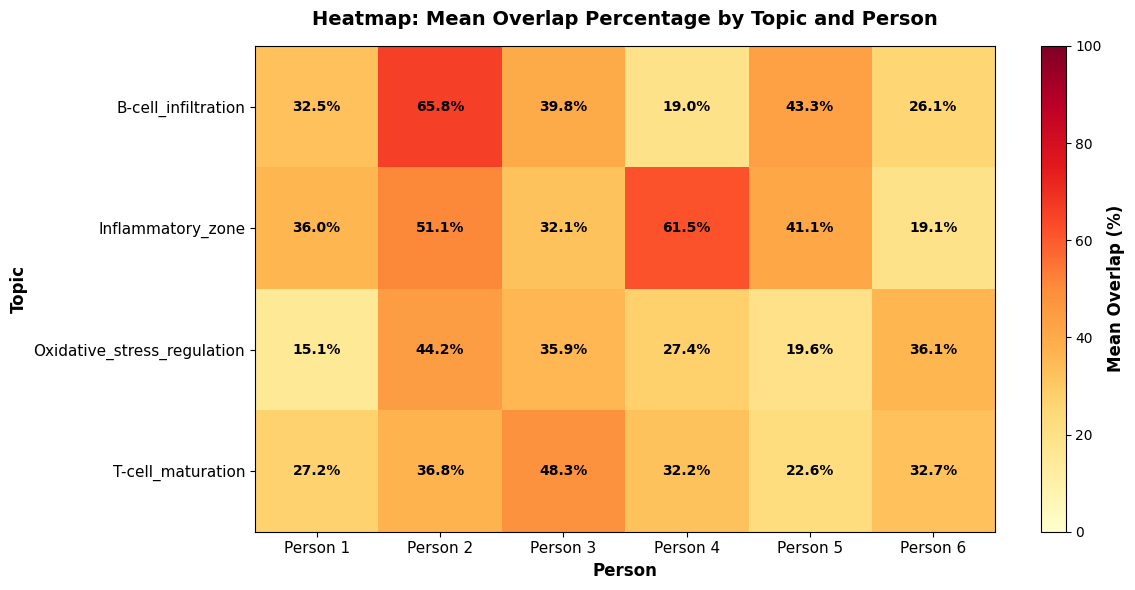

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import math

# Define file paths
base_dir = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

# Circle parameters (same as plotting code)
circle_radius = 400

# Function to calculate overlap percentage between two circles
def calculate_circle_overlap(center1, center2, radius):
    """
    Calculate overlap percentage between two circles of equal radius.
    Returns: overlap_area / circle_area * 100
    Formula: area = 2 * r^2 * arccos(d/(2r)) - (d/2) * sqrt(4r^2 - d^2)
    """
    x1, y1 = center1[0], center1[1]
    x2, y2 = center2[0], center2[1]
    
    # Distance between centers
    d = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    r = radius
    
    # If circles don't overlap
    if d >= 2 * r:
        return 0.0
    
    # If circles are concentric (complete overlap)
    if d == 0:
        return 100.0
    
    # Calculate overlap area using circle intersection formula for equal circles
    # area = 2 * r^2 * arccos(d/(2r)) - (d/2) * sqrt(4r^2 - d^2)
    try:
        area = 2 * r**2 * math.acos(d / (2 * r)) - (d / 2) * math.sqrt(4 * r**2 - d**2)
    except (ValueError, ZeroDivisionError):
        # Handle edge cases
        if d >= 2 * r:
            return 0.0
        else:
            return 100.0
    
    # Overlap percentage (area of intersection / area of one circle * 100)
    circle_area = math.pi * r**2
    overlap_percent = (area / circle_area) * 100
    
    # Ensure result is between 0 and 100
    return max(0.0, min(100.0, overlap_percent))

# Function to match GAT ROIs with Person ROIs and calculate overlap
def calculate_overlap_for_person(gat_data, person_data, radius):
    """
    Match GAT ROIs with Person ROIs and calculate overlap percentage.
    Uses Hungarian algorithm for optimal matching.
    """
    if len(gat_data) == 0 or len(person_data) == 0:
        return []
    
    # Extract coordinates (x, y) - ignoring z for 2D overlap
    gat_coords = gat_data[['x', 'y']].values
    person_coords = person_data[['x', 'y']].values
    
    # Calculate distance matrix
    distance_matrix = cdist(gat_coords, person_coords, metric='euclidean')
    
    # Use Hungarian algorithm for optimal matching
    row_indices, col_indices = linear_sum_assignment(distance_matrix)
    
    overlaps = []
    for i, j in zip(row_indices, col_indices):
        gat_center = (gat_coords[i][0], gat_coords[i][1])
        person_center = (person_coords[j][0], person_coords[j][1])
        overlap = calculate_circle_overlap(gat_center, person_center, radius)
        overlaps.append(overlap)
    
    return overlaps

# Process each CSV file
results = {}
all_overlaps = {f'Person {i}': [] for i in range(1, 7)}

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        print(f"Warning: CSV file not found: {csv_path}")
        continue
    
    # Read CSV file
    df = pd.read_csv(csv_path)
    
    # Extract sheet name
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    # Get GAT data (reference)
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy()
    gat_data = gat_data.sort_values(by='ROI_ID').reset_index(drop=True)
    
    print(f"\n{'='*70}")
    print(f"Processing: {sheet_name}")
    print(f"{'='*70}")
    print(f"GAT ROIs: {len(gat_data)}")
    
    results[sheet_name] = {}
    
    # Process each person
    for person_num in range(1, 7):
        person_name = f'Person {person_num}'
        person_data = df[df.iloc[:, 0] == person_name].copy()
        person_data = person_data.sort_values(by='ROI_ID').reset_index(drop=True)
        
        if len(person_data) == 0:
            print(f"  {person_name}: No data found")
            continue
        
        # Calculate overlaps
        overlaps = calculate_overlap_for_person(gat_data, person_data, circle_radius)
        
        if len(overlaps) > 0:
            avg_overlap = np.mean(overlaps)
            std_overlap = np.std(overlaps)
            results[sheet_name][person_name] = {
                'overlaps': overlaps,
                'mean': avg_overlap,
                'std': std_overlap,
                'min': np.min(overlaps),
                'max': np.max(overlaps)
            }
            all_overlaps[person_name].extend(overlaps)
            
            print(f"  {person_name}:")
            print(f"    Mean overlap: {avg_overlap:.2f}%")
            print(f"    Std dev: {std_overlap:.2f}%")
            print(f"    Min: {np.min(overlaps):.2f}%, Max: {np.max(overlaps):.2f}%")
            print(f"    Individual overlaps: {[f'{o:.1f}%' for o in overlaps]}")

print(f"\n{'='*70}")
print("Summary Statistics Across All Topics")
print(f"{'='*70}")
for person_num in range(1, 7):
    person_name = f'Person {person_num}'
    if len(all_overlaps[person_name]) > 0:
        overall_mean = np.mean(all_overlaps[person_name])
        overall_std = np.std(all_overlaps[person_name])
        print(f"{person_name}: Mean = {overall_mean:.2f}%, Std = {overall_std:.2f}%")

# Create detailed summary table
print(f"\n{'='*100}")
print("DETAILED OVERLAP STATISTICS BY TOPIC AND PERSON")
print(f"{'='*100}\n")

# Create DataFrame for summary table
summary_data = []
for sheet_name in results.keys():
    for person_num in range(1, 7):
        person_name = f'Person {person_num}'
        if person_name in results[sheet_name]:
            stats = results[sheet_name][person_name]
            summary_data.append({
                'Topic': sheet_name,
                'Person': person_name,
                'Mean Overlap (%)': f"{stats['mean']:.2f}",
                'Std Dev (%)': f"{stats['std']:.2f}",
                'Min (%)': f"{stats['min']:.2f}",
                'Max (%)': f"{stats['max']:.2f}",
                'Individual Overlaps': ', '.join([f"{o:.1f}%" for o in stats['overlaps']])
            })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save to CSV
summary_csv_path = base_dir / 'overlap_summary.csv'
summary_df.to_csv(summary_csv_path, index=False)
print(f"\n✓ Summary table saved to: {summary_csv_path}")

# Create heatmap of mean overlaps
fig, ax = plt.subplots(figsize=(12, 6))
heatmap_data = []
for sheet_name in results.keys():
    row = []
    for person_num in range(1, 7):
        person_name = f'Person {person_num}'
        if person_name in results[sheet_name]:
            row.append(results[sheet_name][person_name]['mean'])
        else:
            row.append(0)
    heatmap_data.append(row)

heatmap_data = np.array(heatmap_data)
im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mean Overlap (%)', fontsize=12, fontweight='bold')

# Set ticks and labels
ax.set_xticks(np.arange(len([f'Person {i}' for i in range(1, 7)])))
ax.set_yticks(np.arange(len(results.keys())))
ax.set_xticklabels([f'Person {i}' for i in range(1, 7)], fontsize=11)
ax.set_yticklabels(list(results.keys()), fontsize=11)

# Add text annotations
for i in range(len(results.keys())):
    for j in range(6):
        text = ax.text(j, i, f'{heatmap_data[i, j]:.1f}%',
                      ha="center", va="center", color="black", fontweight='bold', fontsize=10)

ax.set_title('Heatmap: Mean Overlap Percentage by Topic and Person', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Person', fontsize=12, fontweight='bold')
ax.set_ylabel('Topic', fontsize=12, fontweight='bold')

plt.tight_layout()
output_path = base_dir / 'overlap_heatmap.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()
